# VGGT First-Frame Invariance Probe

**Question.** VGGT predicts World Points (WP) and Camera Pose (CP) *relative to the first frame* of its streaming window. If the agent starts somewhere else, the *same* physical scene is expressed in a *different* reference frame. Does this leak into the trained Dreamer (R2Dreamer, L1, 2M-step) representation?

**Design.** For each of several start poses in one HM3D house we run a **forward** episode (start → goal) and a **backward** episode that physically retraces the same path (goal → start). Crucially the backward run gets its own fresh VGGT streaming window (its own first-frame reference). We then match frames by *physical position* and compare:

1. **Raw WP / CP** — what the Dreamer encoder actually ingests.
2. **Umeyama-aligned WP** — how much of the difference is a *benign rigid reference-frame transform* vs. genuine structural disagreement.
3. **RSSM posterior** — categorical Jensen–Shannon divergence of the stochastic state + cosine of the deterministic state.

Consumes the recorded extraction artifacts; the GPU extraction job was retired with the encoder-era vggt adapter. This notebook is pure NumPy/Matplotlib — runs on CPU.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'src').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from src.analysis.invariance_metrics import (
    umeyama, match_by_position, categorical_js, cosine, l2, compare_pair)

ARTIFACT_DIR = REPO / 'output' / 'analysis' / 'invariance'
manifest = json.loads((ARTIFACT_DIR / 'manifest.json').read_text())
print('checkpoint step:', manifest['checkpoint_step'])
print('episodes:', len(manifest['episodes']))
for e in manifest['episodes']:
    print(f"  ep{e['index']:02d} id={e['episode_id']} geo={e['geodesic']:.2f}m "
          f"fwd={e['fwd_steps']} bwd={e['bwd_steps']}")

checkpoint step: 2000000
episodes: 5
  ep00 id=22958 geo=4.35m fwd=30 bwd=24
  ep01 id=23057 geo=4.97m fwd=30 bwd=30
  ep02 id=16747 geo=4.38m fwd=30 bwd=30
  ep03 id=19490 geo=4.89m fwd=30 bwd=26
  ep04 id=19946 geo=4.26m fwd=30 bwd=30


In [2]:
def load_episode(idx):
    d = np.load(ARTIFACT_DIR / f'episode_{idx:02d}.npz')
    return {k: d[k] for k in d.files}

episodes = [load_episode(e['index']) for e in manifest['episodes']]
ep0 = episodes[0]
print('arrays in episode 0:')
for k in sorted(ep0):
    print(f'  {k:14s} {ep0[k].shape} {ep0[k].dtype}')

arrays in episode 0:
  bwd_action     (24,) int64
  bwd_cp         (24, 9) float32
  bwd_deter      (24, 2048) float32
  bwd_embed      (24, 1024) float32
  bwd_logit      (24, 32, 16) float32
  bwd_pos        (24, 3) float32
  bwd_rgb        (24, 259, 259, 3) uint8
  bwd_rot        (24, 4) float32
  bwd_sensor_pos (24, 3) float32
  bwd_sensor_rot (24, 4) float32
  bwd_stoch      (24, 32, 16) float32
  bwd_wp         (24, 37, 37, 3) float32
  fwd_action     (30,) int64
  fwd_cp         (30, 9) float32
  fwd_deter      (30, 2048) float32
  fwd_embed      (30, 1024) float32
  fwd_logit      (30, 32, 16) float32
  fwd_pos        (30, 3) float32
  fwd_rgb        (30, 259, 259, 3) uint8
  fwd_rot        (30, 4) float32
  fwd_sensor_pos (30, 3) float32
  fwd_sensor_rot (30, 4) float32
  fwd_stoch      (30, 32, 16) float32
  fwd_wp         (30, 37, 37, 3) float32
  geodesic       () float32
  goal_pos       (3,) float32
  start_pos      (3,) float32


## 1. Match forward ↔ backward frames by physical position

The backward run retraces the path, so each forward viewpoint has a nearby backward viewpoint. We match by nearest agent position (≤ 0.3 m). Note: because the agent physically turns around, the camera *heading* at a matched position is roughly opposite — we report that so it stays transparent.

In [3]:
MATCH_MAX_DIST = 0.30
matches = []
for i, ep in enumerate(episodes):
    pairs, dists = match_by_position(ep['fwd_pos'], ep['bwd_pos'], MATCH_MAX_DIST)
    matches.append(pairs)
    md = f'{np.mean(dists):.3f}' if dists else 'n/a'
    print(f'ep{i:02d}: {len(pairs):2d} matched pairs (of {len(ep["fwd_pos"])} fwd frames), mean match dist={md} m')

ep00: 19 matched pairs (of 30 fwd frames), mean match dist=0.073 m
ep01: 30 matched pairs (of 30 fwd frames), mean match dist=0.045 m
ep02: 30 matched pairs (of 30 fwd frames), mean match dist=0.049 m
ep03: 30 matched pairs (of 30 fwd frames), mean match dist=0.081 m
ep04: 30 matched pairs (of 30 fwd frames), mean match dist=0.070 m


## 2. Per-frame divergence metrics

For every matched pair we compute the full metric bundle. `wp_rmse_raw` is the raw point-to-point disagreement of the two WP clouds; `wp_rmse_aligned` is the residual *after* the best rigid+scale (Umeyama) transform. If `aligned ≪ raw`, the two runs encode the **same geometry in different frames** — the invariance gap is a reference-frame artefact, exactly the VGGT property under test.

In [4]:
rows = []
for i, (ep, pairs) in enumerate(zip(episodes, matches)):
    for (f, b) in pairs:
        m = compare_pair(ep['fwd_wp'][f], ep['bwd_wp'][b], ep['fwd_cp'][f], ep['bwd_cp'][b],
                         ep['fwd_logit'][f], ep['bwd_logit'][b], ep['fwd_deter'][f], ep['bwd_deter'][b],
                         ep['fwd_embed'][f], ep['bwd_embed'][b])
        m['episode'] = i; m['f'] = f; m['b'] = b
        rows.append(m)

import pandas as pd
df = pd.DataFrame(rows)
cols = ['wp_cosine','embed_cosine','wp_rmse_raw','wp_rmse_aligned','wp_residual_ratio','cp_l2','latent_js','deter_cosine']
summary = df[cols].agg(['mean','std','min','max']).T
print('Aggregate over', len(df), 'matched pairs across', df.episode.nunique(), 'episodes:')
summary.round(4)

Aggregate over 139 matched pairs across 5 episodes:


,mean,std,min,max
wp_cosine,0.5006,0.4797,-0.6974,0.9885
embed_cosine,0.4565,0.2276,-0.0635,0.8918
wp_rmse_raw,0.9015,0.3901,0.2018,1.8204
wp_rmse_aligned,0.3109,0.0960,0.1022,0.7011
wp_residual_ratio,0.4125,0.1984,0.0754,0.8960
cp_l2,0.7534,0.4387,0.1039,1.7890
latent_js,0.4399,0.0892,0.2101,0.5956
deter_cosine,0.6369,0.0593,0.5018,0.7965


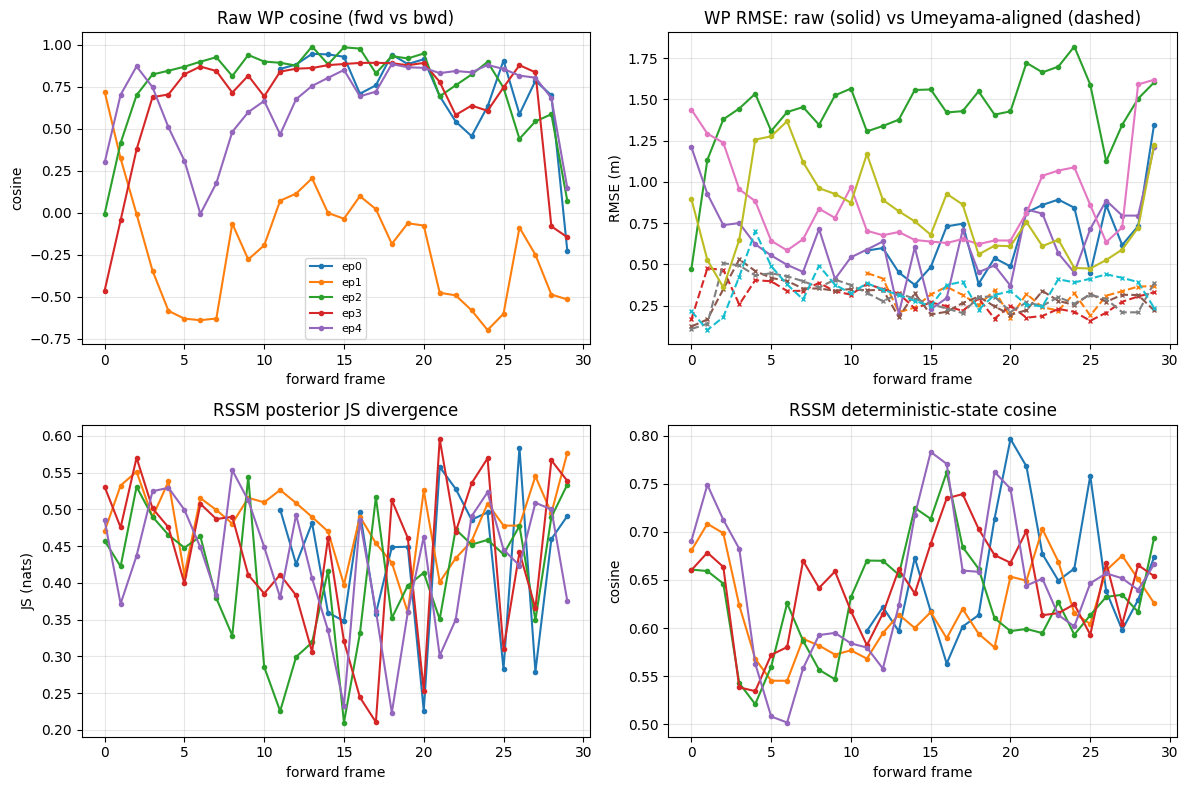

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for i in df.episode.unique():
    s = df[df.episode == i].sort_values('f')
    ax[0,0].plot(s.f, s.wp_cosine, marker='o', ms=3, label=f'ep{i}')
    ax[0,1].plot(s.f, s.wp_rmse_raw, marker='o', ms=3)
    ax[0,1].plot(s.f, s.wp_rmse_aligned, marker='x', ms=3, ls='--')
    ax[1,0].plot(s.f, s.latent_js, marker='o', ms=3)
    ax[1,1].plot(s.f, s.deter_cosine, marker='o', ms=3)
ax[0,0].set(title='Raw WP cosine (fwd vs bwd)', xlabel='forward frame', ylabel='cosine')
ax[0,1].set(title='WP RMSE: raw (solid) vs Umeyama-aligned (dashed)', xlabel='forward frame', ylabel='RMSE (m)')
ax[1,0].set(title='RSSM posterior JS divergence', xlabel='forward frame', ylabel='JS (nats)')
ax[1,1].set(title='RSSM deterministic-state cosine', xlabel='forward frame', ylabel='cosine')
ax[0,0].legend(fontsize=8); [a.grid(alpha=.3) for a in ax.ravel()]
plt.tight_layout(); plt.show()

## 3. WP point clouds for one matched pair

Same physical place, two reference frames. Left: raw WP clouds (forward vs backward) — they sit in different frames. Right: backward cloud after the Umeyama transform onto the forward frame. Tight overlap ⇒ same geometry, different frame.

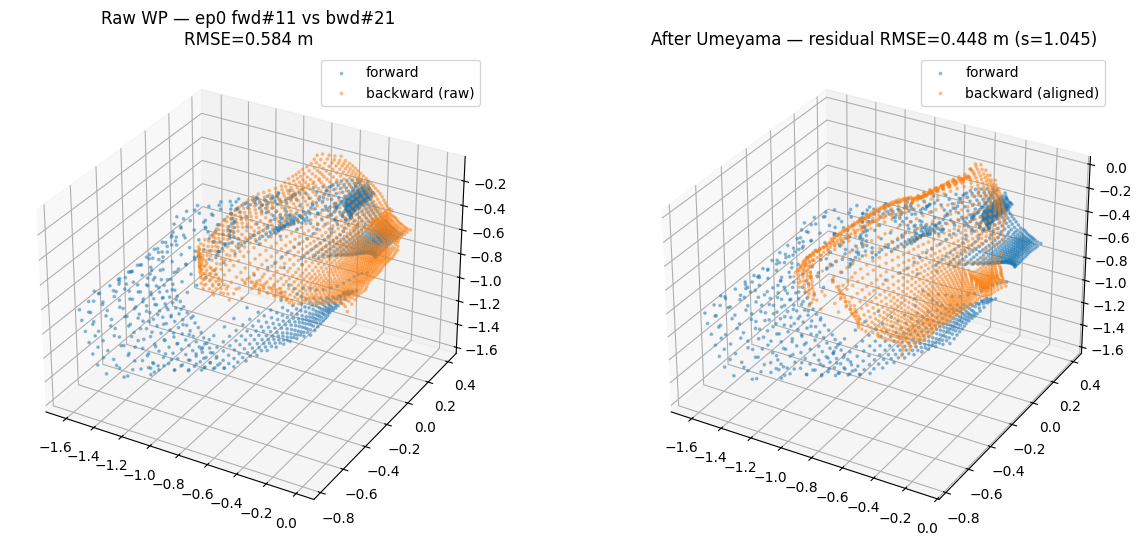

In [6]:
ep_i, pair_k = 0, 0
f, b = matches[ep_i][pair_k]
fwp = episodes[ep_i]['fwd_wp'][f].reshape(-1, 3)
bwp = episodes[ep_i]['bwd_wp'][b].reshape(-1, 3)
al = umeyama(bwp, fwp, with_scale=True)
fig = plt.figure(figsize=(13, 5.5))
a1 = fig.add_subplot(121, projection='3d')
a1.scatter(*fwp.T, s=3, alpha=.4, label='forward')
a1.scatter(*bwp.T, s=3, alpha=.4, label='backward (raw)')
a1.set_title(f'Raw WP — ep{ep_i} fwd#{f} vs bwd#{b}\nRMSE={al["rmse_before"]:.3f} m'); a1.legend()
a2 = fig.add_subplot(122, projection='3d')
a2.scatter(*fwp.T, s=3, alpha=.4, label='forward')
a2.scatter(*al['aligned'].T, s=3, alpha=.4, label='backward (aligned)')
a2.set_title(f'After Umeyama — residual RMSE={al["rmse_after"]:.3f} m (s={al["s"]:.3f})'); a2.legend()
plt.tight_layout(); plt.show()

## 4. Generate the HTML findings report

Writes a self-contained HTML report (figures embedded as base64) to `docs/`, matching the existing `docs/*.html` analysis style.

In [7]:
from scripts.r2dreamer.invariance_report import build_report
out_html = build_report(ARTIFACT_DIR, REPO / 'docs' / '3d-invariance-vggt-first-frame.html')
print('wrote', out_html)

wrote /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/docs/3d-invariance-vggt-first-frame.html
